# Lab 1: Linear Regression

In this practice session, you are invited to train a linear regression model using gradient descent method. After the learning phase, your model should predict house prices in the region of _Ile-de-France_ given their areas (in m²) and their numbers of rooms.

We will also enhace the perfomence of the learning algorithm using different implementation techniques like vectorization and features normalization.

## Import libraries and load data
Import **numpy** library that support matrix operation and **matplotlib** library for plotting data.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1

The _house.csv_ file contains $d=3$ columns that represent the area, the number of rooms and the price of $n=600$ houses (one per row). 

- Open this file with a file editor to understand more the data. 
- Load the data and check its size.

**Hint:** You could use [loadtxt](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.loadtxt.html) function from numpy library.

In [2]:
data=np.loadtxt('house.csv')
data

array([[122.,   6., 361.],
       [125.,   6., 759.],
       [ 79.,   4., 584.],
       ...,
       [ 86.,   4., 332.],
       [ 64.,   3., 246.],
       [100.,   5., 249.]])

## Question 2
* Extract the house area and price columns respectively in $X$ and $y$ lists.
* Scatter prices against areas.

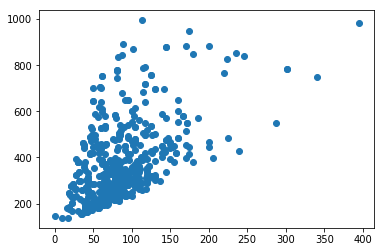

In [3]:
X=data[:,0]
y=data[:,2]
plt.scatter(X,y)
plt.show()

## Question 3
The cost function we will use for this linear model training is the **Mean Squared Error** function defined by $$L(w) = MSE(X \cdot w, y) = \frac{1}{2n} \sum_{i=1}^{n}{( x_i \cdot w - y_i)^2}$$
First of all, transform $X$ and $y$ to be two $(n,1)$-numpy arrays.

In [4]:
X=np.array(X).reshape(-1,1)
y=np.array(y).reshape(-1,1)

## Question 4
Implement the mean squared error cost function. Then implement its gradient : $$\nabla L(w) = \partial_{w} MSE(X \cdot w, y) = \frac{1}{n} \sum_{i=1}^{n}{(x_i \cdot w - y_i)~x_i}$$

In [5]:
def mse(y,y_pred):
    return .5*np.mean((y_pred-y)**2)

def dmse(X,y,y_pred):
    return np.mean((y_pred-y)*X)

**Note :** Check [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html). 

## Question 5
The update equation of the gradient descent algorithm is given by: $$w^{(t+1)}=w^{(t)}-\alpha \nabla L(w^{(t)}) $$
Where $\alpha$ represents the step or the **learning rate**.
* Compute three steps of the gradient descent with different values of $\alpha$.
 * Hint : To select the best value of $\alpha$, we could start by small values and increase it progressively. We should select the highest value of $\alpha$ before the algorithm diverge. The rule of thumbs for varying $\alpha$ is to increase it by factor of 3. For example, we could select $\alpha=0.0001,~0.0003,~0.001,~0.003,~0.01,~0,03,~0.1 \dots$
* For each $\alpha$, plot $w \to L(w)$, your initial point $(w_0, L(w_0))$ and the three points associated to $w_1$, $w_2$ and $w_3$ you've just computed. 
* What is the best $\alpha$ according to you ?

In [6]:
alphas=[0.1,0.01,0.001,0.0001,0.00001,0.000001]
n_steps=5
for alpha in alphas:
    print("alpha = {}".format(alpha))
    w=1
    print("   w0 = 1")
    for i in range(n_steps):
        w=w-alpha*dmse(X,y,w*X)
        print("   w{} = {}".format(i+1,w))
    print("")

alpha = 0.1
   w0 = 1
   w1 = 2547.2803333333336
   w2 = -2278593.125690556
   w3 = 2041330464.3196084
   w4 = -1828770121844.2961
   w5 = 1638343337010296.0

alpha = 0.01
   w0 = 1
   w1 = 255.62803333333335
   w2 = -22326.61079690556
   w3 = 1980428.168046963
   w4 = -175638218.69574237
   w5 = 15576856318.820955

alpha = 0.001
   w0 = 1
   w1 = 26.462803333333333
   w2 = -176.44306196905555
   w3 = 1440.4562886305123
   w4 = -11444.156514814773
   w5 = 91229.6722755464

alpha = 0.0001
   w0 = 1
   w1 = 3.5462803333333333
   w2 = 3.8088739803094445
   w3 = 3.8359548254660125
   w4 = 3.838747627892267
   w5 = 3.8390356449518164

alpha = 1e-05
   w0 = 1
   w1 = 1.2546280333333333
   w2 = 1.4864191998030944
   w3 = 1.697421673293821
   w4 = 1.889499932777506
   w5 = 2.0643512373898343

alpha = 1e-06
   w0 = 1
   w1 = 1.0254628033333333
   w2 = 1.0506972379980308
   w3 = 1.0757053521679774
   w4 = 1.1004891756475659
   w5 = 1.1250507200364492



## Question 6

Implement the gradient descent algorithm, taking as input the gradient function, the learning rate, one or several stopping criterions and an initial parameter $w_0$.

## Question 7
Compute the optimal parameter $w^*$. Compare on the same frame the actual prices and the ones predicted by the linear model against the areas.

## Question 8
Introduce the bias term.

## Question 9
Same as question 7. Be careful to what should happend to $w_0$ and $\alpha$. 

## Question 10
Add the number of rooms in $X$ and normalize it. Same as question 9. Comment.

## Question 11
You could also try to add other feature columns to the matrix X like $area^2$ or $area^{0.5}\dots~$ and see the effect on the model and the error. Is it still linear ?

## Question 12

Create a LinearRegression class object.

## Question 13
Compare your results with $\verb!sklearn!$'s [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

## Question 14

How much would cost a $330m^2$ flat with $5$ rooms ?